# Corridor Two-Body Kinematic Plausibility Simulation

Author: Andrew Jelen<br>
Approach: minimum-phases analytical reconstruction of the contested 3-second two-body movement sequence, with kinematic demands scored against published biomechanical reference distributions.

## Cross-references

- `references/incident/geometry.md` - corridor topology, actor positions, props (briefcase, stroller, swung door panel), body-relative directions
- `references/incident/events_reconstruction.md` - minimum-viable stage reconstruction with ELBO-style methodology
- `references/incident/testimony_victim.md` - Victoria's five chronologically ordered accounts
- `references/incident/testimony_3rd_party.md` - court social curator's observations
- `references/incident/testimony_victoria_inconsistencies.md` - evolution of Victoria's narrative across five tellings
- `docs/impact_analysis.md` - impact-force consequences against thoracic-impact biomechanical literature

## Corrected geometry (summary)

Corridor runs W to E. Two segments:

- **Segment 1** (entrance, narrower) on the west; segment 2 (wider) on the east contains both doors
- **Apartment door** on the N wall of segment 2, opens to the W (~1 m wide panel projects into the corridor)
- **Elevator door** on the S wall of segment 2, slightly west of the apartment door
- **N-S distance** between the two doors: ~2 m (this is the throw distance)

At the contested moment:

- **Victoria** stands inside the apartment door envelope on its W side, facing S out into the corridor. Her body-relative left = E, right = W, front = S, back = N
- **Andrew** stands with his back pressed flat against the elevator door (S wall), facing N toward Victoria. Maximum-retreat position
- **Cecilia** stands in segment 1 west of both, facing E, overlooking segment 2 with a clear view of the apartment door area
- **[Box]** aluminium briefcase ~50 × 30 cm on the floor at the east edge of the elevator door, blocking Andrew's east step-out
- **[Str]** stroller in segment 2 NW corner
- **D** apartment door panel swung W into the corridor, partially obstructing Cecilia's eastward line of sight

## Methodology - minimum-phases reconstruction (ELBO-style lower bound)

This notebook computes a **lower bound** on the required kinematic demand using the smallest set of separable physical phases that maps the verbatim claim. No additional gestures, transitional pauses, hand re-positionings or body adjustments are added; each phase gets the maximum duration the 3 s budget allows, minimising the required peak velocity, acceleration and force.

Structurally identical to ELBO:

| Variational inference (ELBO) | Min-phases reconstruction |
|---|---|
| Tractable lower bound on $\log p(x)$ | Tractable lower bound on $D(M_{\text{true}})$ |
| Improving the bound never hurts the true | Violation of the bound implies violation of the true |

If $D_{\min}(q^\star) \gg R$ (lower-bound demand greatly exceeds the population reference $R$), then $D(M_{\text{true}}) \gg R$ too - regardless of how the actual motion is decomposed. Full derivation in `references/incident/events_reconstruction.md`.

## Scoring rubric

| z-score above reference mean | Verdict |
|---|---|
| z <= 1 | plausible |
| 1 < z <= 2 | strained |
| 2 < z <= 3 | implausible |
| z > 3 | extreme |

Worst-case cooperation model: Victoria is treated as fully passive (no resistive friction or grip). Adding any resistance only increases the actor's required force, so the passive model is a lower bound on the demand.


In [1]:
# Imports
from __future__ import annotations

import math  # standard library
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Rich console for tabular output
from rich.console import Console
from rich.table import Table

# Project modules
from henryk_simulations.corridor import (
    PhaseResult,
    PlausibilityScore,
    Verdict,
    compute_scenario,
    default_library,
    default_scenario,
    score_phase,
)
from henryk_simulations.corridor.kinematics import (
    G,
    actor_effort_for_translation,
    compute_phase_kinematics,
)
from henryk_simulations.corridor.plausibility import (
    score_reach_phase,
    score_rotation_phase,
    score_translation_phase,
)
from henryk_simulations.corridor.plots import (
    plot_acceleration_over_time,
    plot_corridor_overhead,
    plot_force_over_time,
    plot_impulse_over_time,
    plot_per_phase_demand,
    plot_phase_timeline,
    plot_reference_overlay,
    plot_speed_over_time,
    plot_verdict_summary,
)

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


2026-05-13 18:26:29.894 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
# Reproducibility - bootstrap CIs sample from references
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)


## Configuration

In [3]:
# ============================================================================
# CONFIGURATION - edit any value below to rerun the analysis with different
# parameters. Phase durations, impact stopping distance and reference values
# are all configurable here.
# ============================================================================
from rich import box

# --- Per-phase time budget (seconds). Total time = sum. ---
# Kinematic peaks scale as v_peak = 2*s/t and a_peak = 4*s/t^2, so shorter
# phases produce higher required peaks.
PHASE_DURATIONS = {
    "pull":       1.0,   # s - A retreats backward pulling V toward elevator
    "swap-throw": 1.0,   # s - positions swap, V impacts elevator, V rotates 180 deg
    "swap-back":  1.0,   # s - positions swap back, A rotates 180 deg, V rotates 180 deg
}

# --- Impact stopping distance (centimetres) ---
# Distance V's torso travels while decelerating against the elevator door.
# Combines tissue compression, door panel flex and small body travel.
# 2.0 cm is the baseline used in docs/impact_analysis.md.
STOPPING_DISTANCE_CM = 2.0
STOPPING_DISTANCE_M = STOPPING_DISTANCE_CM / 100.0

# --- Build the scenario from the editable knobs above ---
sc = default_scenario(phase_durations=PHASE_DURATIONS)
lib = default_library()

# --- Configuration overview (rich Table) ---
cfg_table = Table(
    title="Scenario configuration",
    box=box.ROUNDED,
    show_header=True,
    header_style="bold cyan",
    title_justify="left",
    title_style="bold",
)
cfg_table.add_column("Parameter", style="bold")
cfg_table.add_column("Value", justify="right")
cfg_table.add_row("corridor width (door-to-door)", f"{sc.geometry.corridor_width:.2f} m")
cfg_table.add_row("corridor lateral extent", f"{sc.geometry.corridor_lateral:.2f} m")
cfg_table.add_row("Andrew mass", f"{sc.bodies.h_mass:.0f} kg")
cfg_table.add_row("Victoria mass", f"{sc.bodies.m_mass:.0f} kg")
cfg_table.add_row("Andrew yaw inertia", f"{sc.bodies.yaw_inertia_h:.2f} kg·m²")
cfg_table.add_row("Victoria yaw inertia", f"{sc.bodies.yaw_inertia_m:.2f} kg·m²")
cfg_table.add_row("total time budget", f"{sc.total_time:.2f} s")
cfg_table.add_row("phase count", f"{len(sc.phases)}")
cfg_table.add_row("impact stopping distance", f"{STOPPING_DISTANCE_CM:.1f} cm")
console.print(cfg_table)

# --- Phase-duration knobs (the configurable time budget) ---
dur_table = Table(
    title="Phase time budget (editable in PHASE_DURATIONS)",
    box=box.ROUNDED,
    show_header=True,
    header_style="bold cyan",
    title_justify="left",
    title_style="bold",
)
dur_table.add_column("phase", style="bold")
dur_table.add_column("duration", justify="right")
for name, dur in PHASE_DURATIONS.items():
    dur_table.add_row(name, f"{dur:.2f} s")
dur_table.add_row("[bold]total[/]", f"[bold]{sum(PHASE_DURATIONS.values()):.2f} s[/]")
console.print(dur_table)


Scenario configuration                        
╭───────────────────────────────┬────────────╮
│ Parameter                     │      Value │
├───────────────────────────────┼────────────┤
│ corridor width (door-to-door) │     2.00 m │
│ corridor lateral extent       │     1.50 m │
│ Andrew mass                   │      90 kg │
│ Victoria mass                 │      70 kg │
│ Andrew yaw inertia            │ 1.80 kg·m² │
│ Victoria yaw inertia          │ 1.40 kg·m² │
│ total time budget             │     3.00 s │
│ phase count                   │          3 │
│ impact stopping distance      │     2.0 cm │
╰───────────────────────────────┴────────────╯

Phase time budget        
(editable in             
PHASE_DURATIONS)         
╭────────────┬──────────╮
│ phase      │ duration │
├────────────┼──────────┤
│ pull       │   1.00 s │
│ swap-throw │   1.00 s │
│ swap-back  │   1.00 s │
│ total      │   3.00 s │
╰────────────┴──────────╯

/home/lab/workspace/private/henryk/henryk-simulations/src/henryk_simulations/corridor/plots.py:420: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  briefcase = mpatches.Rectangle(
/home/lab/workspace/private/henryk/henryk-simulations/src/henryk_simulations/corridor/plots.py:442: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  stroller = mpatches.Rectangle(


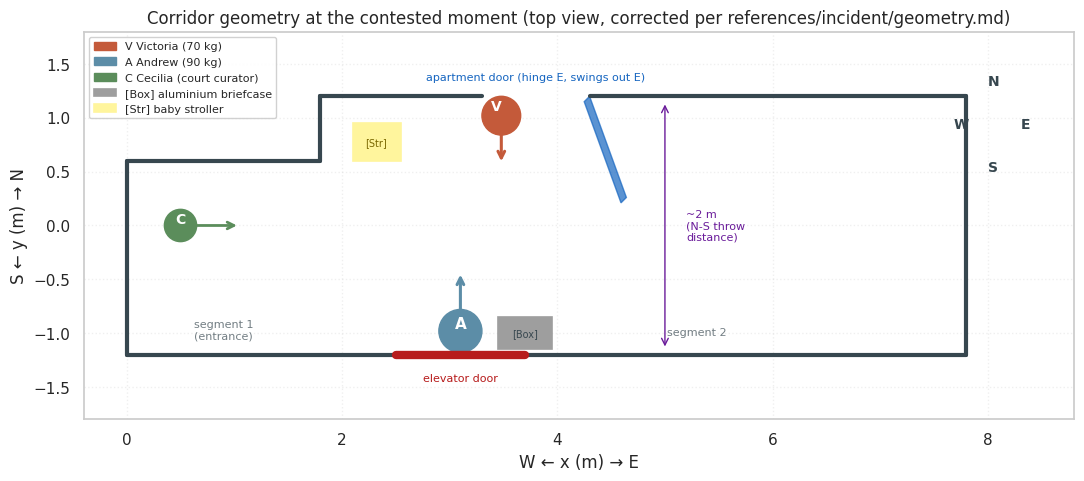

In [4]:
# Corridor overhead schematic
fig_corr = plot_corridor_overhead(
    sc.geometry,
    sc.bodies,
    out_path=FIG_DIR / "01-corridor-geometry.png",
)
plt.show()


## Phase decomposition

In [5]:
# Phase decomposition table
ph_table = Table(title="3-phase decomposition", show_header=True, header_style="bold")
for col in ("#", "phase", "kind", "body", "duration (s)", "translation (m)", "rotation (deg)", "notes"):
    ph_table.add_column(col)
notes_map = {
    "pull": "A retreats backward toward elevator pulling V along (1.5 m of V's 2 m total)",
    "swap-throw": "Positions exchange + V's back impacts elevator door + V rotates 180 deg tracking A",
    "swap-back": "Positions exchange back; A rotates 180 deg to face away (back to elevator); V rotates 180 deg",
}
for idx, phase in enumerate(sc.phases):
    deg = phase.rotation * 180 / math.pi if phase.rotation else 0
    ph_table.add_row(
        str(idx + 1),
        phase.name,
        phase.kind,
        phase.body,
        f"{phase.duration:.2f}",
        f"{phase.translation:.2f}" if phase.translation else "-",
        f"{deg:.0f}" if deg else "-",
        notes_map.get(phase.name, ""),
    )
console.print(ph_table)


                                               3-phase decomposition                                               
┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ # ┃ phase      ┃ kind      ┃ body ┃ duration (s) ┃ translation (m) ┃ rotation (deg) ┃ notes                     ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1 │ pull       │ translate │ M    │ 1.00         │ 1.50            │ -              │ A retreats backward       │
│   │            │           │      │              │                 │                │ toward elevator pulling V │
│   │            │           │      │              │                 │                │ along (1.5 m of V's 2 m   │
│   │            │           │      │              │                 │                │ total)                    │
│ 2 │ swap-throw │ translate │ M    │ 1.00         │ 0.22            │ 180            │ Positions exchange + V's  │
│   │            │           │      │              │                 │                │ back impacts elevator     │
│   │            │           │      │              │                 │                │ door + V rotates 180 deg  │
│   │            │           │      │              │                 │                │ tracking A                │
│ 3 │ swap-back  │ rotate    │ H    │ 1.00         │ -               │ 180            │ Positions exchange back;  │
│   │            │           │      │              │                 │                │ A rotates 180 deg to face │
│   │            │           │      │              │                 │                │ away (back to elevator);  │
│   │            │           │      │              │                 │                │ V rotates 180 deg         │
└───┴────────────┴───────────┴──────┴──────────────┴─────────────────┴────────────────┴───────────────────────────┘

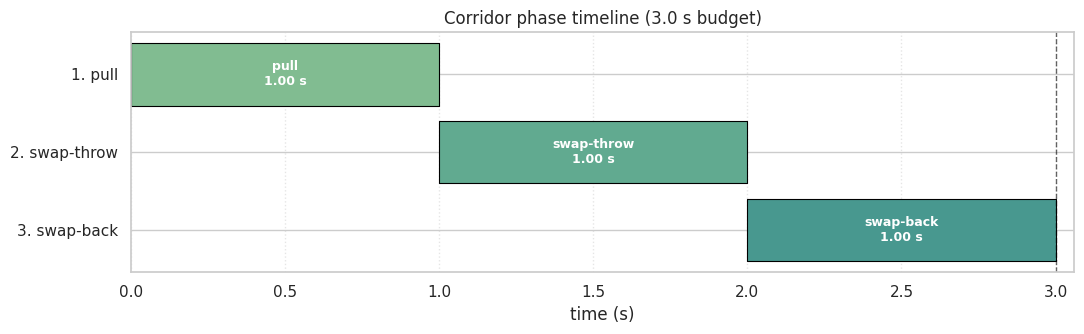

In [6]:
# Phase timeline gantt
fig_timeline = plot_phase_timeline(
    sc.phases,
    sc.phase_starts,
    total_time=sc.total_time,
    out_path=FIG_DIR / "01-phase-timeline.png",
)
plt.show()


## Kinematic demands per phase

In [7]:
# Per-phase kinematics (no-resistance / worst-case scenario)
rows = []
results = compute_scenario(sc, resistance="passive", impact_stopping_distance=STOPPING_DISTANCE_M)
for r in results:
    rows.append({
        "phase": r.phase_name,
        "kind": r.kind,
        "body": r.body,
        "mass_kg": r.mass,
        "duration_s": r.duration,
        "distance_m": r.distance,
        "v_start_m_s": round(r.v_start, 3),
        "v_end_m_s": round(r.v_end, 3),
        "v_peak_m_s": round(r.v_peak, 3),
        "a_avg_m_s2": round(r.a_avg, 3),
        "a_peak_m_s2": round(r.a_peak, 3),
        "a_peak_g": round(r.a_peak_g, 3),
        "f_avg_N": round(r.f_avg, 1),
        "f_peak_N": round(r.f_peak, 1),
        "impulse_net_N_s": round(r.impulse_net, 1),
        "ke_start_J": round(r.ke_start, 1),
        "ke_end_J": round(r.ke_end, 1),
        "ke_J": round(r.kinetic_energy, 1),
        "work_done_J": round(r.work_done, 1),
        "omega_peak_rad_s": round(r.omega_peak, 3),
        "alpha_peak_rad_s2": round(r.alpha_peak, 3),
        "torque_peak_Nm": round(r.torque_peak, 1),
        "rot_ke_J": round(r.rotational_ke, 1),
    })
results_df = pd.DataFrame(rows)
results_df.head(20)


,phase,kind,body,mass_kg,duration_s,distance_m,v_start_m_s,v_end_m_s,v_peak_m_s,a_avg_m_s2,...,f_peak_N,impulse_net_N_s,ke_start_J,ke_end_J,ke_J,work_done_J,omega_peak_rad_s,alpha_peak_rad_s2,torque_peak_Nm,rot_ke_J
0,pull,translate,M,70.0,1.0,1.50,0.0,3.0,3.00,3.0,...,420.0,210.0,0.0,315.0,315.0,315.0,0.000,0.000,0.0,0.0
1,swap-throw,translate,M,70.0,1.0,0.22,3.0,0.0,0.44,-3.0,...,61.6,-210.0,315.0,0.0,6.8,-315.0,6.283,12.566,17.6,27.6
2,swap-back,rotate,H,90.0,1.0,0.00,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6.283,12.566,22.6,35.5
3,swap-back/M,translate,M,70.0,1.0,0.40,0.0,0.8,0.80,0.8,...,112.0,56.0,0.0,22.4,22.4,22.4,6.283,12.566,17.6,27.6


In [8]:
# Full per-phase deconstruction: triangular-peak quantities + continuous-velocity
# model + rotation kinematics + impact analysis (where applicable).
all_results = compute_scenario(sc, resistance="passive", impact_stopping_distance=STOPPING_DISTANCE_M)

# --- Continuous-velocity translation (v_start, v_end, a_avg, F_avg, impulse, KE) ---
cv_table = Table(
    title="Translation kinematics per phase (continuous-velocity model)",
    show_header=True, header_style="bold",
)
for col in ("phase", "T (s)", "s (m)",
            "v_start (m/s)", "v_end (m/s)",
            "a_avg (m/s²)", "a_avg (g)",
            "F_avg (N)",
            "impulse (N·s)",
            "KE_start (J)", "KE_end (J)", "work (J)"):
    cv_table.add_column(col)
for r in all_results:
    if r.kind != "translate":
        cv_table.add_row(
            r.phase_name, f"{r.duration:.2f}", "-",
            f"{r.v_start:.2f}", f"{r.v_end:.2f}",
            "-", "-", "-", "-", "-", "-", "-",
        )
        continue
    cv_table.add_row(
        r.phase_name,
        f"{r.duration:.2f}",
        f"{r.distance:.2f}",
        f"{r.v_start:.2f}",
        f"{r.v_end:.2f}",
        f"{r.a_avg:+.2f}",
        f"{r.a_avg / 9.80665:+.2f}",
        f"{r.f_avg:.0f}",
        f"{r.impulse_net:+.0f}",
        f"{r.ke_start:.0f}",
        f"{r.ke_end:.0f}",
        f"{r.work_done:+.0f}",
    )
console.print(cv_table)

# --- Triangular-peak quantities (a_peak, F_peak, KE_at_peak) ---
peak_table = Table(
    title="Translation peaks per phase (triangular profile within phase)",
    show_header=True, header_style="bold",
)
for col in ("phase", "v_peak (m/s)", "a_peak (m/s²)", "a_peak (g)",
            "F_peak (N)", "KE_peak (J)", "impulse_accel (N·s)"):
    peak_table.add_column(col)
for r in all_results:
    if not r.v_peak:
        peak_table.add_row(r.phase_name, "-", "-", "-", "-", "-", "-")
        continue
    peak_table.add_row(
        r.phase_name,
        f"{r.v_peak:.2f}",
        f"{r.a_peak:.2f}",
        f"{r.a_peak_g:.2f}",
        f"{r.f_peak:.0f}",
        f"{r.kinetic_energy:.0f}",
        f"{r.impulse:.0f}",
    )
console.print(peak_table)

# --- Rotation kinematics ---
rot_table = Table(
    title="Rotation kinematics per phase",
    show_header=True, header_style="bold",
)
for col in ("phase", "T (s)", "θ (deg)",
            "ω_peak (rad/s)", "ω_peak (deg/s)",
            "α_peak (rad/s²)",
            "τ_peak (N·m)",
            "L_peak (kg·m²/s)",
            "rotational KE (J)"):
    rot_table.add_column(col)
for r in all_results:
    if not r.omega_peak:
        rot_table.add_row(r.phase_name, f"{r.duration:.2f}", "-", "-", "-", "-", "-", "-", "-")
        continue
    rot_table.add_row(
        r.phase_name,
        f"{r.duration:.2f}",
        f"{r.angle * 180 / math.pi:.0f}",
        f"{r.omega_peak:.2f}",
        f"{r.omega_peak * 180 / math.pi:.0f}",
        f"{r.alpha_peak:.2f}",
        f"{r.torque_peak:.1f}",
        f"{r.angular_momentum_peak:.2f}",
        f"{r.rotational_ke:.1f}",
    )
console.print(rot_table)

# --- Impact analysis (only for phases where an impact is computed) ---
impacts = [r for r in all_results if r.impact is not None and r.impact.v_impact > 0]
if impacts:
    imp_table = Table(
        title="Impact analysis (constant-decel over stopping distance)",
        show_header=True, header_style="bold",
    )
    for col in ("phase", "v_impact (m/s)", "v_impact (km/h)",
                "stopping d (cm)",
                "KE_impact (J)",
                "momentum (N·s)",
                "a_impact (m/s²)", "a_impact (g)",
                "F_impact (N)", "F_impact (kN)",
                "t_stop (ms)"):
        imp_table.add_column(col)
    for r in impacts:
        i = r.impact
        imp_table.add_row(
            r.phase_name,
            f"{i.v_impact:.2f}",
            f"{i.v_impact * 3.6:.1f}",
            f"{i.stopping_distance * 100:.1f}",
            f"{i.ke_impact:.0f}",
            f"{i.momentum:.0f}",
            f"{i.a_impact:.0f}",
            f"{i.a_impact_g:.1f}",
            f"{i.f_impact:.0f}",
            f"{i.f_impact / 1000:.2f}",
            f"{i.t_stop * 1000:.1f}",
        )
    console.print(imp_table)


                           Translation kinematics per phase (continuous-velocity model)                            
┏━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃         ┃       ┃       ┃ v_start ┃ v_end   ┃ a_avg   ┃ a_avg   ┃ F_avg   ┃ impul… ┃ KE_sta… ┃ KE_end ┃ work    ┃
┃ phase   ┃ T (s) ┃ s (m) ┃ (m/s)   ┃ (m/s)   ┃ (m/s²)  ┃ (g)     ┃ (N)     ┃ (N·s)  ┃ (J)     ┃ (J)    ┃ (J)     ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ pull    │ 1.00  │ 1.50  │ 0.00    │ 3.00    │ +3.00   │ +0.31   │ 210     │ +210   │ 0       │ 315    │ +315    │
│ swap-t… │ 1.00  │ 0.22  │ 3.00    │ 0.00    │ -3.00   │ -0.31   │ 210     │ -210   │ 315     │ 0      │ -315    │
│ swap-b… │ 1.00  │ -     │ 0.00    │ 0.00    │ -       │ -       │ -       │ -      │ -       │ -      │ -       │
│ swap-b… │ 1.00  │ 0.40  │ 0.00    │ 0.80    │ +0.80   │ +0.08   │ 56      │ +56    │ 0       │ 22     │ +22     │
└─────────┴───────┴───────┴─────────┴─────────┴─────────┴─────────┴─────────┴────────┴─────────┴────────┴─────────┘

                       Translation peaks per phase (triangular profile within phase)                        
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ phase       ┃ v_peak (m/s) ┃ a_peak (m/s²) ┃ a_peak (g) ┃ F_peak (N) ┃ KE_peak (J) ┃ impulse_accel (N·s) ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ pull        │ 3.00         │ 6.00          │ 0.61       │ 420        │ 315         │ 210                 │
│ swap-throw  │ 0.44         │ 0.88          │ 0.09       │ 62         │ 7           │ 31                  │
│ swap-back   │ -            │ -             │ -          │ -          │ -           │ -                   │
│ swap-back/M │ 0.80         │ 1.60          │ 0.16       │ 112        │ 22          │ 56                  │
└─────────────┴──────────────┴───────────────┴────────────┴────────────┴─────────────┴─────────────────────┘

                                           Rotation kinematics per phase                                           
┏━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃             ┃       ┃         ┃ ω_peak      ┃ ω_peak      ┃ α_peak      ┃ τ_peak     ┃ L_peak      ┃ rotational ┃
┃ phase       ┃ T (s) ┃ θ (deg) ┃ (rad/s)     ┃ (deg/s)     ┃ (rad/s²)    ┃ (N·m)      ┃ (kg·m²/s)   ┃ KE (J)     ┃
┡━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ pull        │ 1.00  │ -       │ -           │ -           │ -           │ -          │ -           │ -          │
│ swap-throw  │ 1.00  │ 180     │ 6.28        │ 360         │ 12.57       │ 17.6       │ 8.80        │ 27.6       │
│ swap-back   │ 1.00  │ 180     │ 6.28        │ 360         │ 12.57       │ 22.6       │ 11.31       │ 35.5       │
│ swap-back/M │ 1.00  │ 180     │ 6.28        │ 360         │ 12.57       │ 17.6       │ 8.80        │ 27.6       │
└─────────────┴───────┴─────────┴─────────────┴─────────────┴─────────────┴────────────┴─────────────┴────────────┘

                              Impact analysis (constant-decel over stopping distance)                              
┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃         ┃ v_impa… ┃ v_impa… ┃ stopping ┃ KE_imp… ┃ momentum ┃ a_impa… ┃ a_impact ┃ F_impa… ┃ F_impact ┃ t_stop  ┃
┃ phase   ┃ (m/s)   ┃ (km/h)  ┃ d (cm)   ┃ (J)     ┃ (N·s)    ┃ (m/s²)  ┃ (g)      ┃ (N)     ┃ (kN)     ┃ (ms)    ┃
┡━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ swap-t… │ 3.00    │ 10.8    │ 2.0      │ 315     │ 210      │ 225     │ 22.9     │ 15750   │ 15.75    │ 13.3    │
└─────────┴─────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴─────────┘

In [9]:
# Actor effort and friction cap during the pull phase
throw = next(r for r in compute_scenario(sc, resistance="passive") if r.phase_name == "pull")
eff = actor_effort_for_translation(throw, actor_mass=sc.bodies.h_mass)
console.print("[bold]Actor effort budget[/bold]")
console.print(f"  required force on M : {eff['f_required_N']:.0f} N")
console.print(f"  friction cap (H mass {sc.bodies.h_mass:.0f} kg, mu 0.30): {eff['f_friction_cap_N']:.0f} N")
console.print(f"  feasible            : {eff['feasible']}")
console.print(f"  headroom ratio      : {eff['headroom_ratio']:.2f}")


Actor effort budget

required force on M : 420 N

friction cap (H mass 90 kg, mu 0.30): 265 N

feasible            : False

headroom ratio      : 0.63

## Reference distributions

In [10]:
# Reference distributions
ref_rows = []
for key, ref in lib.refs.items():
    lo, hi = ref.ci(0.95)
    ref_rows.append({
        "key": key,
        "name": ref.name,
        "units": ref.units,
        "mean": round(ref.mean, 3),
        "sd": round(ref.sd, 3),
        "ci95_lo": round(lo, 3),
        "ci95_hi": round(hi, 3),
        "population": ref.population,
        "citation": ref.citation,
    })
ref_df = pd.DataFrame(ref_rows)
ref_df


,key,name,units,mean,sd,ci95_lo,ci95_hi,population,citation
0,push_force_single_arm,"single-arm peak push, untrained male",N,400.0,100.0,204.004,595.996,"adult male, recreational",Daams 1994; Mital & Kumar 1995
1,push_force_two_arm,"two-arm peak push, standing",N,800.0,200.0,408.007,1191.993,"adult male, recreational",Daams 1994; Chaffin & Andersson 1991
2,sprint_acceleration_recreational,"sprint acceleration, recreational",m/s^2,3.0,0.8,1.432,4.568,"adult male, recreational","Mero, Komi & Gregor 1992; di Prampero 2005"
3,sprint_acceleration_elite,"sprint acceleration, elite sprinter",m/s^2,5.0,0.5,4.020,5.980,elite male sprinter,"Mero, Komi & Gregor 1992"
4,throw_velocity_object_5kg,"overhand throw velocity, 5 kg object",m/s,8.0,2.5,3.100,12.900,"adult male, recreational",Cross 2004; Atwater 1979
5,throw_kinetic_energy,"overhand throw KE budget, 5 kg object",J,160.0,80.0,3.203,316.797,"adult male, recreational",Cross 2004; van den Tillaar & Ettema 2004
6,yaw_angular_velocity_pivot,standing pivot yaw angular velocity,rad/s,3.5,1.0,1.540,5.460,"adult male, recreational","Hodgson, Lewis & Drury 2008"
7,whole_body_yaw_inertia,whole-body yaw moment of inertia,kg*m^2,1.5,0.4,0.716,2.284,"adult male, recreational","Plagenhoef, Evans & Abdelnour 1983"
8,arm_swing_velocity,arm swing forward velocity,m/s,2.5,0.8,0.932,4.068,"adult male, recreational","Marteniuk, MacKenzie & Leavitt 1990"


## Plausibility scoring

In [11]:
# Score each phase against the most appropriate reference for each kinematic demand
results_passive = compute_scenario(sc, resistance="passive", impact_stopping_distance=STOPPING_DISTANCE_M)

# Map phase -> chosen references. A translate phase that also has a rotation
# (Victoria's 360 deg yaw during the throw) is scored for both quantities.
def score_all(results):
    scores: list[PlausibilityScore] = []
    for r in results:
        if r.kind == "translate" and r.f_peak > 0:
            scores += score_translation_phase(
                r,
                accel_ref=lib["sprint_acceleration_recreational"],
                force_ref=lib["push_force_two_arm"],
                energy_ref=lib["throw_kinetic_energy"] if r.phase_name in ("pull", "swap-throw") else None,
            )
        if r.omega_peak > 0:
            scores += score_rotation_phase(r, omega_ref=lib["yaw_angular_velocity_pivot"])
        if r.kind == "reach" and r.reach_v_peak > 0:
            scores += score_reach_phase(r, arm_ref=lib["arm_swing_velocity"])
    return scores

scores = score_all(results_passive)
score_df = pd.DataFrame([
    {
        "phase": s.phase_name,
        "quantity": s.quantity_label,
        "required": round(s.required_value, 3),
        "units": s.units,
        "ref": s.reference_name,
        "ref_mean": round(s.reference_mean, 3),
        "ref_sd": round(s.reference_sd, 3),
        "z": round(s.z, 2),
        "x_mean": round(s.multiple_of_mean, 2),
        "verdict": s.verdict.value,
    }
    for s in scores
])
score_df


,phase,quantity,required,units,ref,ref_mean,ref_sd,z,x_mean,verdict
0,pull,peak acceleration,6.000,m/s^2,"sprint acceleration, recreational",3.0,0.8,3.75,2.00,extreme
1,pull,peak force,420.000,N,"two-arm peak push, standing",800.0,200.0,-1.90,0.53,plausible
2,pull,kinetic energy,315.000,J,"overhand throw KE budget, 5 kg object",160.0,80.0,1.94,1.97,strained
3,swap-throw,peak acceleration,0.880,m/s^2,"sprint acceleration, recreational",3.0,0.8,-2.65,0.29,plausible
4,swap-throw,peak force,61.600,N,"two-arm peak push, standing",800.0,200.0,-3.69,0.08,plausible
5,swap-throw,kinetic energy,6.776,J,"overhand throw KE budget, 5 kg object",160.0,80.0,-1.92,0.04,plausible
6,swap-throw,peak yaw angular velocity,6.283,rad/s,standing pivot yaw angular velocity,3.5,1.0,2.78,1.80,implausible
7,swap-back,peak yaw angular velocity,6.283,rad/s,standing pivot yaw angular velocity,3.5,1.0,2.78,1.80,implausible
8,swap-back/M,peak acceleration,1.600,m/s^2,"sprint acceleration, recreational",3.0,0.8,-1.75,0.53,plausible
9,swap-back/M,peak force,112.000,N,"two-arm peak push, standing",800.0,200.0,-3.44,0.14,plausible


In [12]:
# Per-phase summary table: peak values + verdict bands per (phase, quantity)
summary_table = Table(title="Per-phase peak demands and verdicts", show_header=True, header_style="bold")
for col in ("phase", "quantity", "required", "ref mean +/- sd", "x mean", "z", "verdict"):
    summary_table.add_column(col)

verdict_style = {
    "plausible": "green",
    "strained": "yellow",
    "implausible": "red",
    "extreme": "bold red",
}
for s in scores:
    summary_table.add_row(
        s.phase_name,
        s.quantity_label,
        f"{s.required_value:,.2f} {s.units}",
        f"{s.reference_mean:.2f} +/- {s.reference_sd:.2f} {s.units}",
        f"{s.multiple_of_mean:.2f} x",
        f"{s.z:+.2f}",
        f"[{verdict_style.get(s.verdict.value, 'white')}]{s.verdict.value}[/]",
    )
console.print(summary_table)


                                     Per-phase peak demands and verdicts                                     
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┓
┃ phase       ┃ quantity                  ┃ required   ┃ ref mean +/- sd     ┃ x mean ┃ z     ┃ verdict     ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━┩
│ pull        │ peak acceleration         │ 6.00 m/s^2 │ 3.00 +/- 0.80 m/s^2 │ 2.00 x │ +3.75 │ extreme     │
│ pull        │ peak force                │ 420.00 N   │ 800.00 +/- 200.00 N │ 0.53 x │ -1.90 │ plausible   │
│ pull        │ kinetic energy            │ 315.00 J   │ 160.00 +/- 80.00 J  │ 1.97 x │ +1.94 │ strained    │
│ swap-throw  │ peak acceleration         │ 0.88 m/s^2 │ 3.00 +/- 0.80 m/s^2 │ 0.29 x │ -2.65 │ plausible   │
│ swap-throw  │ peak force                │ 61.60 N    │ 800.00 +/- 200.00 N │ 0.08 x │ -3.69 │ plausible   │
│ swap-throw  │ kinetic energy            │ 6.78 J     │ 160.00 +/- 80.00 J  │ 0.04 x │ -1.92 │ plausible   │
│ swap-throw  │ peak yaw angular velocity │ 6.28 rad/s │ 3.50 +/- 1.00 rad/s │ 1.80 x │ +2.78 │ implausible │
│ swap-back   │ peak yaw angular velocity │ 6.28 rad/s │ 3.50 +/- 1.00 rad/s │ 1.80 x │ +2.78 │ implausible │
│ swap-back/M │ peak acceleration         │ 1.60 m/s^2 │ 3.00 +/- 0.80 m/s^2 │ 0.53 x │ -1.75 │ plausible   │
│ swap-back/M │ peak force                │ 112.00 N   │ 800.00 +/- 200.00 N │ 0.14 x │ -3.44 │ plausible   │
│ swap-back/M │ peak yaw angular velocity │ 6.28 rad/s │ 3.50 +/- 1.00 rad/s │ 1.80 x │ +2.78 │ implausible │
└─────────────┴───────────────────────────┴────────────┴─────────────────────┴────────┴───────┴─────────────┘

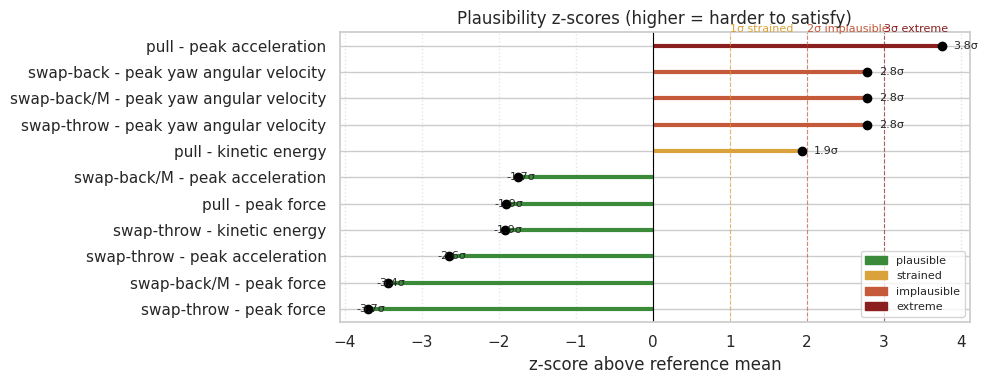

In [13]:
# Lollipop summary of z-scores
fig_verdict = plot_verdict_summary(scores, out_path=FIG_DIR / "01-verdict-summary.png")
plt.show()


## Visualisations

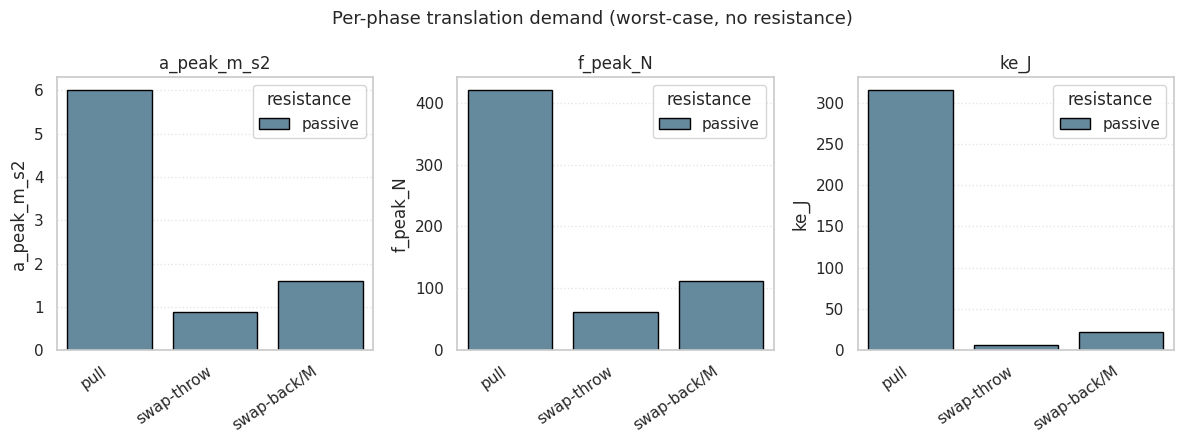

In [14]:
# Per-phase translation demand (worst-case, no resistance)
demand_df = results_df[results_df["a_peak_m_s2"] > 0].copy()
demand_df["resistance"] = "passive"
fig_demand = plot_per_phase_demand(
    demand_df,
    columns=["a_peak_m_s2", "f_peak_N", "ke_J"],
    out_path=FIG_DIR / "01-per-phase-demand.png",
    title="Per-phase translation demand (worst-case, no resistance)",
)
plt.show()


## Time-series: speed, acceleration, force, impulse

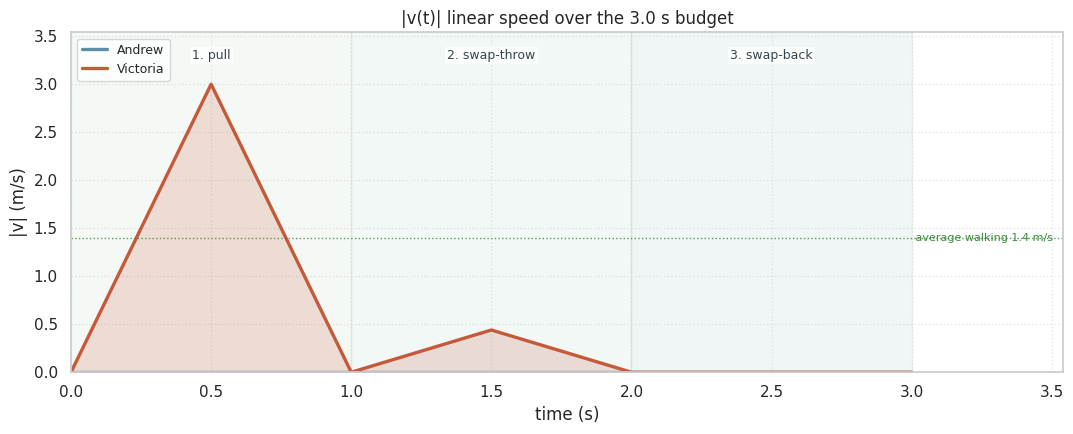

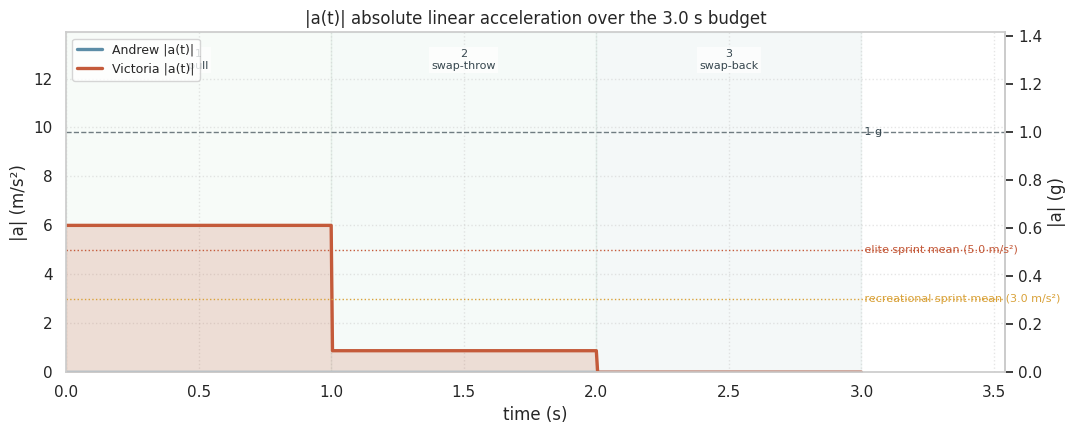

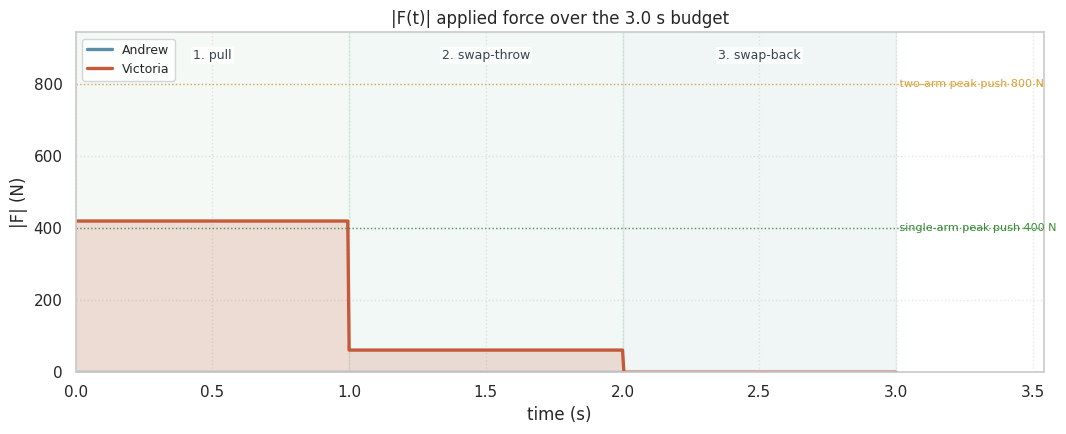

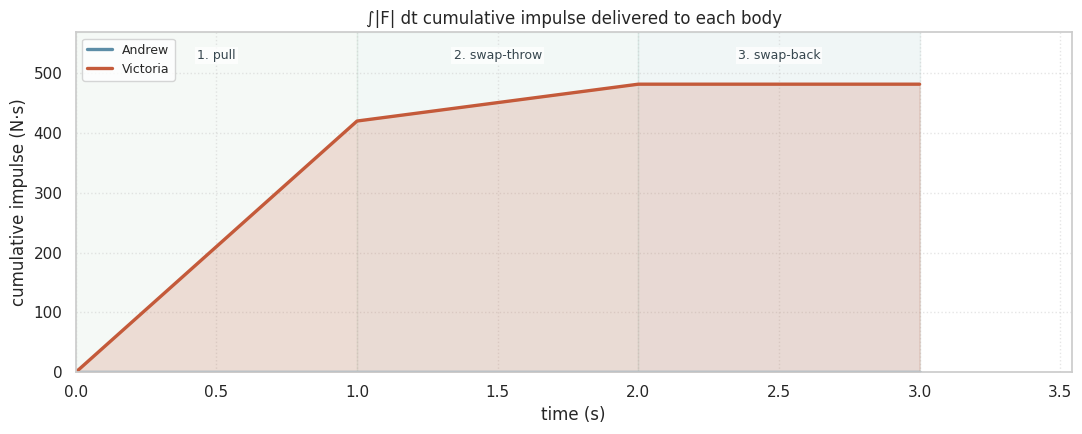

In [15]:
# Four time-series plots: speed, acceleration, force, cumulative impulse
fig_v = plot_speed_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-speed-timeline.png"
)
plt.show()

fig_accel = plot_acceleration_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-acceleration-timeline.png"
)
plt.show()

fig_F = plot_force_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-force-timeline.png"
)
plt.show()

fig_p = plot_impulse_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-impulse-timeline.png"
)
plt.show()


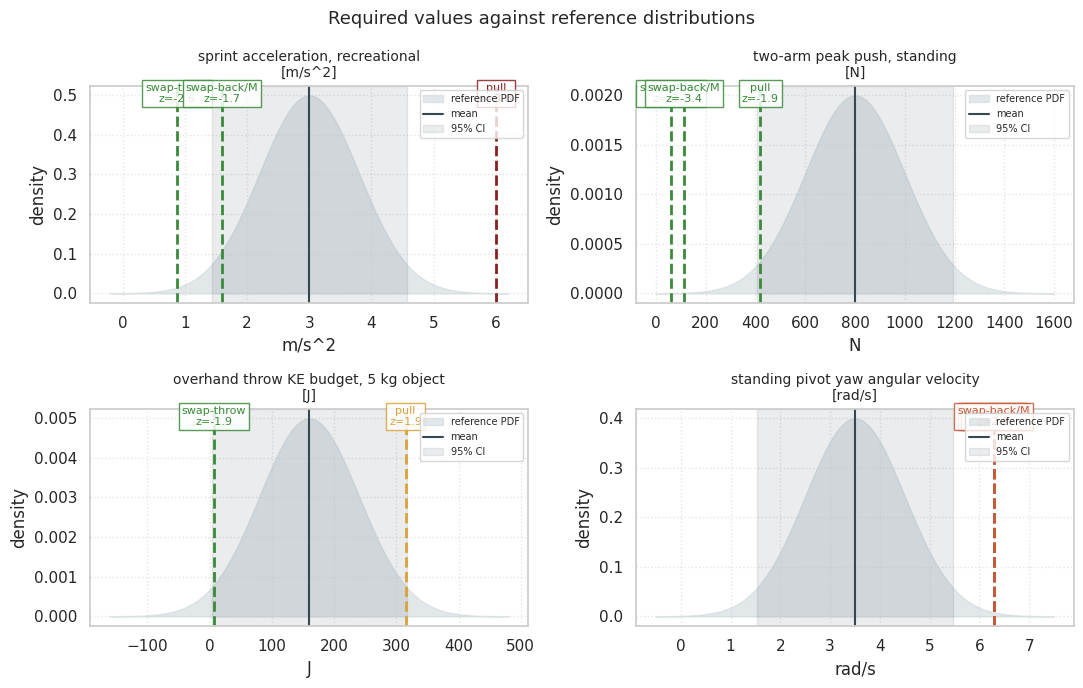

In [16]:
# Required values overlaid on reference distributions
# Pick the union of references that received at least one score
ref_used = []
for s in scores:
    if not any(r.name == s.reference_name for r in ref_used):
        ref_used.append(next(r for r in lib.refs.values() if r.name == s.reference_name))
fig_overlay = plot_reference_overlay(
    scores,
    ref_used,
    out_path=FIG_DIR / "01-reference-overlay.png",
)
plt.show()


## Throw energy budget

In [17]:
# Energy budget for the pull phase (largest translational demand)
throw_r = next(r for r in results_passive if r.phase_name == "pull")
push_budget_two_arm = lib["push_force_two_arm"].mean
throw_ke_ref = lib["throw_kinetic_energy"]

console.print(f"[bold]Throw energy budget[/bold]")
console.print(f"  kinetic energy delivered to M : {throw_r.kinetic_energy:,.0f} J")
console.print(f"  reference for 5 kg overhand throw: {throw_ke_ref.mean:.0f} +/- {throw_ke_ref.sd:.0f} J")
console.print(f"  multiple of reference mean     : {throw_r.kinetic_energy / throw_ke_ref.mean:.1f} x")
console.print(f"  z-score above reference mean   : {throw_ke_ref.z(throw_r.kinetic_energy):.1f}")
console.print(f"  force required (Newton 2nd law): {throw_r.f_peak:,.0f} N")
console.print(f"  two-arm push budget (Daams 1994): {push_budget_two_arm:,.0f} N")


Throw energy budget

kinetic energy delivered to M : 315 J

reference for 5 kg overhand throw: 160 +/- 80 J

multiple of reference mean     : 2.0 x

z-score above reference mean   : 1.9

force required (Newton 2nd law): 420 N

two-arm push budget (Daams 1994): 800 N

## Verdict tally and export

In [18]:
# Final verdict tally and export of the result table for the markdown report
verdict_counts = score_df["verdict"].value_counts().to_dict()
console.print("[bold]Verdict tally across all (phase, quantity) scores[/bold]")
for v in ("plausible", "strained", "implausible", "extreme"):
    console.print(f"  {v:14s}: {verdict_counts.get(v, 0)}")

implausible_or_worse = score_df[score_df["verdict"].isin(["implausible", "extreme"])]
console.print(f"\n[bold]implausible or extreme phases (z > 2):[/bold] {len(implausible_or_worse)}")
console.print(implausible_or_worse[["phase", "quantity", "required", "ref_mean", "z", "verdict"]].to_string(index=False))

# Persist for the verdict report
score_df.to_csv(FIG_DIR.parent / "01-phase-scores.csv", index=False)
results_df.to_csv(FIG_DIR.parent / "01-phase-kinematics.csv", index=False)


Verdict tally across all (phase, quantity) scores

plausible     : 6

strained      : 1

implausible   : 3

extreme       : 1

implausible or extreme phases (z > 2): 4

phase                  quantity  required  ref_mean    z     verdict
       pull         peak acceleration     6.000       3.0 3.75     extreme
 swap-throw peak yaw angular velocity     6.283       3.5 2.78 implausible
  swap-back peak yaw angular velocity     6.283       3.5 2.78 implausible
swap-back/M peak yaw angular velocity     6.283       3.5 2.78 implausible

## Summary

Refer to `reports/corridor-plausibility.md` for the narrative verdict and embedded figures. The per-phase scores and kinematic table are written to `reports/01-phase-scores.csv` and `reports/01-phase-kinematics.csv` for downstream use.

### Limitations

- Constant-acceleration (triangular velocity) profile per phase is the most charitable interpretation; smoother profiles would require higher peaks.
- Resistance model is a friction-equivalent + constant brake; it does not capture active resistance (lowering centre of mass, bracing, counter-rotation).
- Reference distributions are normal with adult male means and SDs; tail probabilities should be read as approximate.
- The analysis is purely kinematic plausibility against population biomechanics. It does not constitute a forensic conclusion about any specific event.
